In [33]:
%pip install keras tensorflow pandas jupyter scikit-learn matplotlib seaborn pillow



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [34]:
from keras import Sequential
from keras.src.layers import Conv2D, MaxPooling2D, BatchNormalization, Activation, ZeroPadding2D, AveragePooling2D, \
    Dropout, Flatten, Dense
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.layers import Convolution2D, Lambda

shape = (224, 224, 1)
FINAL_CLASSES = 10

from tensorflow.keras.layers import Layer

class RGBToGrayscale(Layer):
    def call(self, inputs):
        return tf.image.rgb_to_grayscale(inputs)

    def compute_output_shape(self, input_shape):
        return input_shape[0], input_shape[1], input_shape[2], 1

def convolutional_block(filters):
    f1, f2, f3 = filters

    return [
        Conv2D(f1, (1, 1), strides=(1, 1), kernel_initializer=glorot_uniform(seed=0)),
        MaxPooling2D((2, 2)),
        BatchNormalization(axis=3),
        Activation('relu'),

        Conv2D(f2, (3, 3), strides=(1, 1), padding='same', kernel_initializer=glorot_uniform(seed=0)),
        BatchNormalization(axis=3),
        Activation('relu'),

        Conv2D(f3, (1, 1), strides=(1, 1), padding='same', kernel_initializer=glorot_uniform(seed=0)),
        BatchNormalization(axis=3),

        Conv2D(f3, (1, 1), strides=(1, 1), kernel_initializer=glorot_uniform(seed=0)),
        MaxPooling2D((2, 2)),
        BatchNormalization(axis=3),

        Activation('relu')
    ]


def identity_block(filters):
    f1, f2, f3 = filters

    return [
        Conv2D(f1, (1, 1), strides=(1, 1), kernel_initializer=glorot_uniform(seed=0)),
        BatchNormalization(axis=3),
        Activation('relu'),

        Conv2D(f2, (3, 3), strides=(1, 1), padding='same', kernel_initializer=glorot_uniform(seed=0)),
        BatchNormalization(axis=3),
        Activation('relu'),

        Conv2D(f3, (1, 1), strides=(1, 1), kernel_initializer=glorot_uniform(seed=0)),
        BatchNormalization(axis=3),
        Activation('relu')
    ]


def res_block(model, filters):
    layers = []

    layers.extend(convolutional_block(filters))
    layers.extend(identity_block(filters))
    layers.extend(identity_block(filters))

    for layer in layers:
        model.add(layer)


def resnet():
    model = Sequential()

    model.add(tf.keras.layers.Input(shape=(224, 224, 3)))

    model.add(RGBToGrayscale(name='to_grayscale'))

    model.add(ZeroPadding2D((3, 3)))
    model.add(Conv2D(64, (7, 7), strides=(2, 2), name='conv1'))
    model.add(BatchNormalization(axis=3, name='bn_conv1'))
    model.add(Activation('relu'))
    model.add(MaxPooling2D((3, 3), strides=(2, 2)))

    res_block(model, [64, 64, 256])
    res_block(model, [128, 128, 512])

    model.add(AveragePooling2D((4, 4), padding='same', name='avg_pool'))
    model.add(Flatten())

    model.add(Dense(1024, activation='relu'))
    model.add(Dropout(0.6)) # evitamos overfitting

    model.add(Dense(FINAL_CLASSES, activation='softmax', name='Dense_final', kernel_initializer=glorot_uniform(seed=0)))

    return model


def get_neural_network_model():
    return resnet()

In [35]:
import tensorflow as tf

tf.keras.backend.clear_session()

NEURAL_NETWORK_TYPE = 'resnet'

In [36]:
model = get_neural_network_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ to_grayscale (RGBToGrayscale)   │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 230, 230, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 112, 112, 64)   │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_conv1 (BatchNormalization)   │ (None, 112, 112, 64)   │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 55, 55, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 55, 55, 64)     │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 27, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 27, 27, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 27, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 27, 27, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 27, 27, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 27, 27, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 27, 27, 256)    │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 27, 27, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 27, 27, 256)    │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 13, 13, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 1,887,242 (7.20 MB)

 Trainable params: 1,878,666 (7.17 MB)

 Non-trainable params: 8,576 (33.50 KB)

In [37]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [38]:
import pandas as pd
original_data = pd.read_csv('./etiquetas.csv')
original_data

,archivo,etiqueta_num,clase
0,8de7791d65ce44deb27f85af20162bf4.png,0,taza
1,2daa3155e5c743b8ac616f8da60bf733.png,0,taza
2,bbbb4678dd814533ac7e30fbffd8c136.png,0,taza
3,f4c5c73ba29d446ab0556c1d9aa356b9.png,0,taza
4,1cb37816290c4dcb8a0a5a386d36d232.png,0,taza
...,...,...,...
995,29d3eb30c6c040dd9adb55370064c30d.png,9,paraguas
996,b68e1c8898ed4df8b55d749fe82d2caa.png,9,paraguas
997,24dd8281482742a794ca4288186beb24.png,9,paraguas
998,c4d9f2986b9549ff826ea074c3880a20.png,9,paraguas


In [39]:
original_data.clase.value_counts()

clase
taza         100
silla        100
reloj        100
bicicleta    100
zapato       100
gafas        100
mochila      100
teclado      100
guitarra     100
paraguas     100
Name: count, dtype: int64

In [40]:
class_mapping = {}
numbers = original_data['etiqueta_num'].unique()

for index, item in enumerate(original_data["clase"].unique()):
   class_mapping[numbers[index]] = item

class_mapping

{np.int64(0): 'taza',
 np.int64(1): 'silla',
 np.int64(2): 'reloj',
 np.int64(3): 'bicicleta',
 np.int64(4): 'zapato',
 np.int64(5): 'gafas',
 np.int64(6): 'mochila',
 np.int64(7): 'teclado',
 np.int64(8): 'guitarra',
 np.int64(9): 'paraguas'}

In [41]:
from pathlib import Path
import numpy as np
from PIL import Image

def load_image_array(image_name: str, folder = 'dataset'):
    dataset_dir = Path(f"./{folder}")
    image_path = dataset_dir / image_name
    if not image_path.exists():
        return None

    try:
        img = Image.open(image_path).convert("RGB")
        return np.array(img)
    except Exception:
        return None

In [42]:
original_data["image_array"] = (
    original_data["archivo"].apply(load_image_array)
)
original_data["image_shrouded"] = (
    original_data["archivo"].apply(lambda x: load_image_array(x, 'dataset_shrouded'))
)

missing_original = original_data["image_array"].isna().sum()
missing_shrouded = original_data["image_shrouded"].isna().sum()

print(f"Imágenes originales no encontradas: {missing_original}")
print(f"Imágenes de pixeles modificadas no encontradas: {missing_shrouded}")
original_data.head()

Imágenes originales no encontradas: 0
Imágenes de pixeles modificadas no encontradas: 0


,archivo,etiqueta_num,clase,image_array,image_shrouded
0,8de7791d65ce44deb27f85af20162bf4.png,0,taza,"[[[255, 255, 255], [255, 255, 255], [255, 255,...","[[[128, 128, 128], [128, 128, 128], [128, 128,..."
1,2daa3155e5c743b8ac616f8da60bf733.png,0,taza,"[[[255, 255, 255], [255, 255, 255], [255, 255,...","[[[128, 128, 128], [128, 128, 128], [128, 128,..."
2,bbbb4678dd814533ac7e30fbffd8c136.png,0,taza,"[[[255, 255, 255], [255, 255, 255], [255, 255,...","[[[128, 128, 128], [128, 128, 128], [128, 128,..."
3,f4c5c73ba29d446ab0556c1d9aa356b9.png,0,taza,"[[[255, 255, 255], [255, 255, 255], [255, 255,...","[[[128, 128, 128], [128, 128, 128], [128, 128,..."
4,1cb37816290c4dcb8a0a5a386d36d232.png,0,taza,"[[[104, 112, 115], [96, 104, 107], [81, 89, 92...","[[[128, 128, 128], [128, 128, 128], [128, 128,..."


In [43]:
from keras.src.callbacks import ModelCheckpoint, EarlyStopping

checkpointer = ModelCheckpoint(filepath = f"models/hackathon_{NEURAL_NETWORK_TYPE}.h5", verbose = 1, save_best_only = True)
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

In [44]:
from sklearn.model_selection import train_test_split

data_ok = original_data.dropna(subset=["image_array", "image_shrouded"]).copy()

X_original = np.stack(data_ok["image_array"].values).astype("float32") / 255.0
y_original = data_ok["etiqueta_num"].values

X_shrouded = np.stack(data_ok["image_shrouded"].values).astype("float32") / 255.0
y_shrouded = data_ok["etiqueta_num"].values

X_combined = np.concatenate([X_original, X_shrouded])
y_combined = np.concatenate([y_original, y_shrouded])

indices = np.random.permutation(len(X_combined))
X = X_combined[indices]
y = y_combined[indices]

print(f"Dataset original: {len(X_original)} imágenes")
print(f"Dataset Modificaciones Pixeles: {len(X_shrouded)} imágenes")
print(f"Dataset combinado: {len(X)} imágenes")

x_train, x_predict, y_train, y_predict = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
)


Dataset original: 1000 imágenes
Dataset Modificaciones Pixeles: 1000 imágenes
Dataset combinado: 2000 imágenes


In [45]:
x_train.shape

(1400, 224, 224, 3)

In [46]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
)

datagen.fit(x_train)


In [47]:
#model.fit(
#    datagen.flow(x_train, y_train, batch_size=32),
#   validation_data=(x_predict, y_predict),
#    epochs=100,
#    callbacks=[checkpointer]
#)

19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step


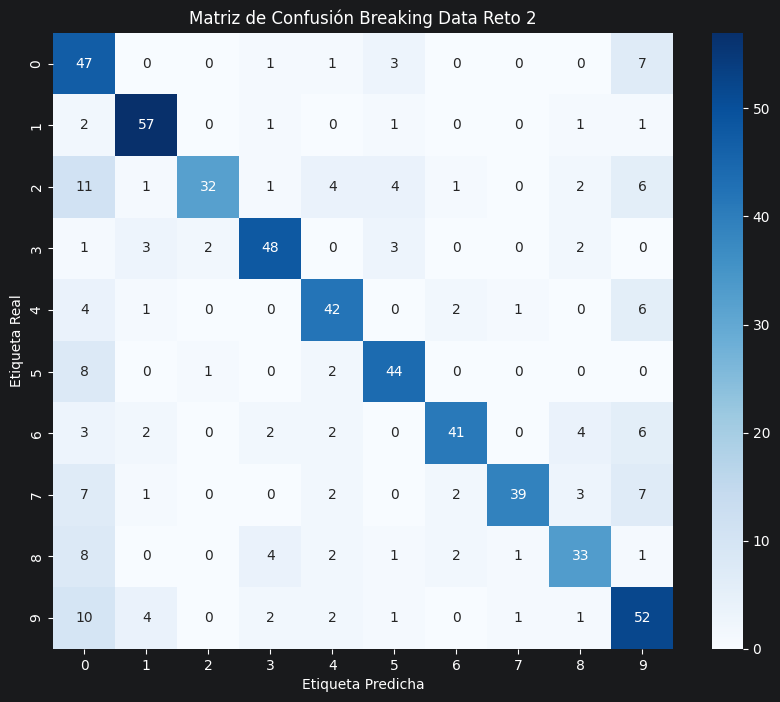

In [48]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

model.load_weights(f"models/final_hackathon_{NEURAL_NETWORK_TYPE}.h5")

y_pred_prob = model.predict(x_predict)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

cm = confusion_matrix(y_predict, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión Breaking Data Reto 2')
plt.ylabel('Etiqueta Real')
plt.xlabel('Etiqueta Predicha')
plt.show()

In [49]:
from sklearn.metrics import f1_score, accuracy_score

model.load_weights(f"models/final_hackathon_{NEURAL_NETWORK_TYPE}.h5")

y_pred_prob = model.predict(x_predict)
y_pred_classes = np.argmax(y_pred_prob, axis=1)

accuracy = accuracy_score(y_predict, y_pred_classes)
f1_macro = f1_score(y_predict, y_pred_classes, average='macro')
f1_weighted = f1_score(y_predict, y_pred_classes, average='weighted')
f1_per_class = f1_score(y_predict, y_pred_classes, average=None)

print(f"Accuracy:    {accuracy:.4f}")
print(f"F1 macro:    {f1_macro:.4f}")
print(f"F1 Score: {f1_weighted:.4f}")
print("F1 por clase:", f1_per_class)

19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step
Accuracy:    0.7250
F1 macro:    0.7298
F1 Score: 0.7289
F1 por clase: [0.5875     0.86363636 0.65979381 0.81355932 0.74336283 0.78571429
 0.75925926 0.75728155 0.67346939 0.65408805]


In [50]:
x = load_image_array('img.png', 'dataset_shrouded')
x = np.expand_dims(x, axis=0).astype("float32") / 255.0
pred_prob = model.predict(x)
pred_prob

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([[1.5044471e-03, 2.0805330e-03, 1.8317493e-03, 5.5044031e-05,
        6.8971813e-03, 1.5507334e-04, 4.1936454e-03, 3.3608789e-03,
        4.1876384e-04, 9.7950268e-01]], dtype=float32)

In [ ]:
class_mapping[np.argmax(pred_prob)]

In [ ]:
import os

test_dataset_path = Path("./dataset_test/dataset_test")
test_images = [f for f in os.listdir(test_dataset_path) if f.endswith('.png')]

print(f"Total de imágenes en dataset_test: {len(test_images)}")

test_data = []
test_filenames = []

for img_file in test_images:
    img_array = load_image_array(img_file, 'dataset_test/dataset_test')

    if img_array is not None:
        test_data.append(img_array)
        test_filenames.append(img_file)

X_test = np.stack(test_data).astype("float32") / 255.0

print(f"Imágenes cargadas correctamente: {len(X_test)}")

test_predictions_prob = model.predict(X_test)
test_predictions_classes = np.argmax(test_predictions_prob, axis=1)
test_predictions_confidence = np.max(test_predictions_prob, axis=1)

results_df = pd.DataFrame({
    'filename': test_filenames,
    'predicted_class': test_predictions_classes,
    'predicted_label': [class_mapping[c] for c in test_predictions_classes],
    'confidence': test_predictions_confidence
})

print("\nPrimeras 10 predicciones:")
print(results_df.head(10))

In [ ]:
# Mostrar una imagen aleatoria del dataset_test con su predicción
import random

random_idx = random.randint(0, len(X_test) - 1)
random_img = X_test[random_idx]
random_filename = test_filenames[random_idx]
random_class = test_predictions_classes[random_idx]
random_confidence = test_predictions_confidence[random_idx]
predicted_label = class_mapping[random_class]

plt.figure(figsize=(8, 6))

if random_img.shape[2] == 1:
    plt.imshow(random_img.squeeze(), cmap='gray')
else:
    plt.imshow(random_img)

plt.title(f'Archivo: {random_filename}\nPredicción: {predicted_label}\nConfianza: {random_confidence:.2%}', fontsize=12)
plt.axis('off')
plt.tight_layout()
plt.show()

print(f"Imagen mostrada: {random_filename}")
print(f"Clase predicha: {predicted_label}")
print(f"Confianza: {random_confidence:.2%}")

In [ ]:
predictions_csv = pd.DataFrame({
    'archivo': test_filenames,
    'etiqueta_num': test_predictions_classes,
    'clase': [class_mapping[c] for c in test_predictions_classes]
})

csv_filename = 'predicciones.csv'
predictions_csv.to_csv(csv_filename, index=False)
